## 1. Import Libraries & Load Dataset

**Tujuan:** Memuat dataset hasil feature selection (`stroke_selected_features.csv`) dan menyiapkan folder output untuk menyimpan seluruh visualisasi yang akan dibuat di notebook ini.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/processed/stroke_selected_features.csv')

sns.set_style('whitegrid')
FIGURES_PATH = '../reports/figures'
os.makedirs(FIGURES_PATH, exist_ok=True)

print(f"Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head(10)

Shape: 5094 baris, 7 kolom


,age,avg_glucose_level,bmi,hypertension,heart_disease,smoking_status,stroke
0,67.0,228.69,36.6,0,1,formerly smoked,1
1,80.0,105.92,32.5,0,1,never smoked,1
2,49.0,171.23,34.4,0,0,smokes,1
3,79.0,174.12,24.0,1,0,never smoked,1
4,81.0,186.21,29.0,0,0,formerly smoked,1
5,74.0,70.09,27.4,1,1,never smoked,1
6,69.0,94.39,22.8,0,0,never smoked,1
7,59.0,76.15,28.1,0,0,Unknown,1
8,78.0,58.57,24.2,0,0,Unknown,1
9,81.0,80.43,29.7,1,0,never smoked,1


**Insight:** Dataset berhasil dimuat (5.094 baris, 7 kolom), folder `reports/figures` siap menampung seluruh visualisasi yang akan dihasilkan pada notebook ini.

## 2. Distribusi Target (stroke)

**Tujuan:** Membuat visualisasi proporsi kelas `stroke` yang rapi dan siap pakai untuk paper, lengkap dengan anotasi persentase — versi lebih polished dari chart eksplorasi yang sudah dibuat di NB04.

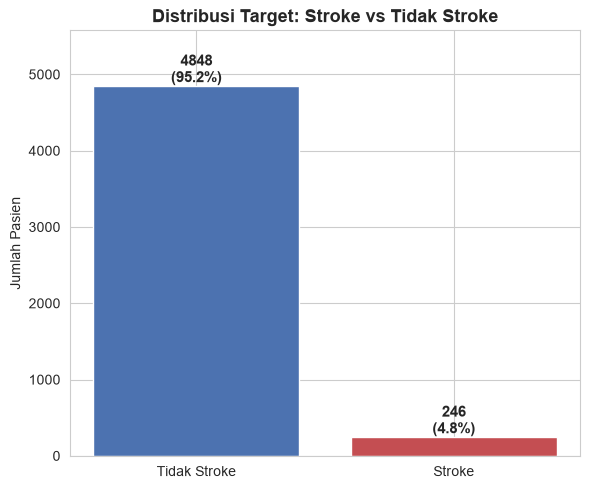

Chart disimpan: ../reports/figures/distribusi_target.png


In [3]:
stroke_counts = df['stroke'].value_counts().sort_index()
stroke_pct = (df['stroke'].value_counts(normalize=True).sort_index() * 100)

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(['Tidak Stroke', 'Stroke'], stroke_counts.values, color=['#4C72B0', '#C44E52'])

for bar, count, pct in zip(bars, stroke_counts.values, stroke_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Distribusi Target: Stroke vs Tidak Stroke', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Pasien')
ax.set_ylim(0, max(stroke_counts.values) * 1.15)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/distribusi_target.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart disimpan: {FIGURES_PATH}/distribusi_target.png")

**Insight:** Visualisasi mengonfirmasi secara visual temuan kuantitatif dari NB04 — imbalance yang sangat signifikan antara kelas tidak-stroke dan stroke.

## 3. Distribusi Fitur Numerik

**Tujuan:** Memvisualisasikan sebaran nilai pada 3 fitur numerik (`age`, `avg_glucose_level`, `bmi`) untuk melihat bentuk distribusinya masing-masing — termasuk mengonfirmasi secara visual sifat bimodal `avg_glucose_level` yang sudah dianalisis sejak awal proyek ini.

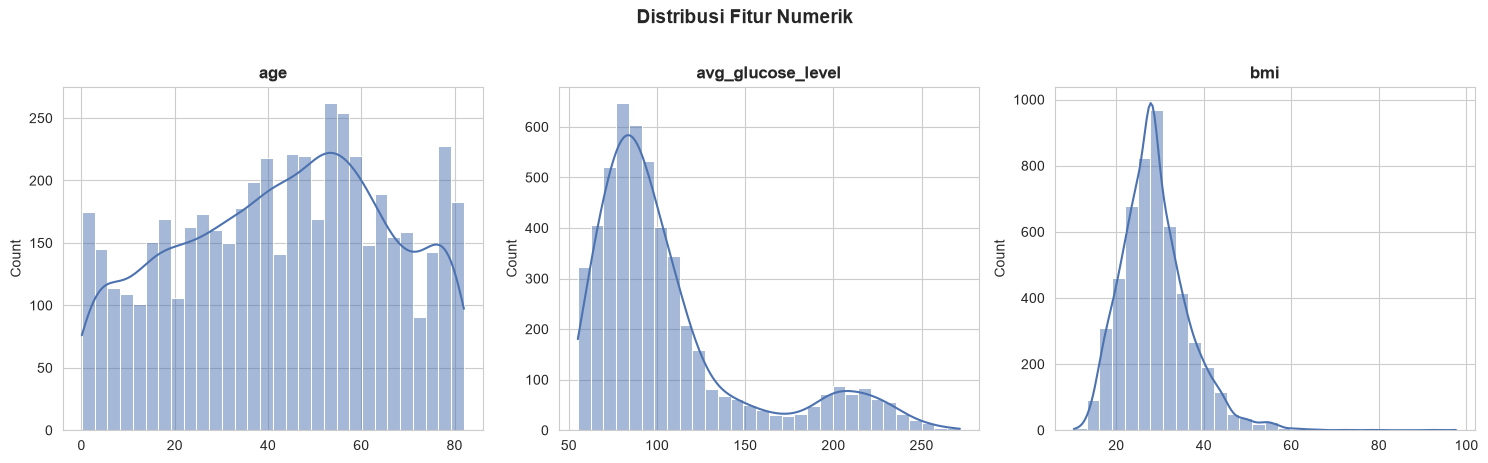

Chart disimpan: ../reports/figures/distribusi_fitur_numerik.png


In [4]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0', bins=30)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/distribusi_fitur_numerik.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart disimpan: {FIGURES_PATH}/distribusi_fitur_numerik.png")

**Insight:** `age` menunjukkan distribusi yang relatif merata dengan sedikit kecenderungan ke kelompok usia dewasa-lansia. `avg_glucose_level` menampilkan pola **bimodal** yang jelas — dua gerombolan terpisah merepresentasikan kelompok pasien non-diabetes dan diabetes, sesuai temuan yang mendasari keputusan penggunaan domain knowledge (bukan IQR) untuk deteksi outlier pada NB03. `bmi` menunjukkan distribusi right-skewed, konsisten dengan alasan pemilihan median (bukan mean) untuk imputasi missing value.

## 4. Perbandingan Fitur Numerik vs Status Stroke

**Tujuan:** Memvisualisasikan perbedaan sebaran nilai fitur numerik antara kelompok stroke dan tidak stroke menggunakan boxplot — versi visual dari hasil uji Mann-Whitney U pada NB05, sekaligus mengonfirmasi secara visual temuan rata-rata usia (42.0 vs 67.7 tahun) yang sudah dibahas sebelumnya.

C:\Users\k2401\AppData\Local\Temp\ipykernel_22316\82386644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\k2401\AppData\Local\Temp\ipykernel_22316\82386644.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Tidak Stroke', 'Stroke'])
C:\Users\k2401\AppData\Local\Temp\ipykernel_22316\82386644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\k2401\AppData\Local\Temp\ipykernel_22316\82386644.py:8:

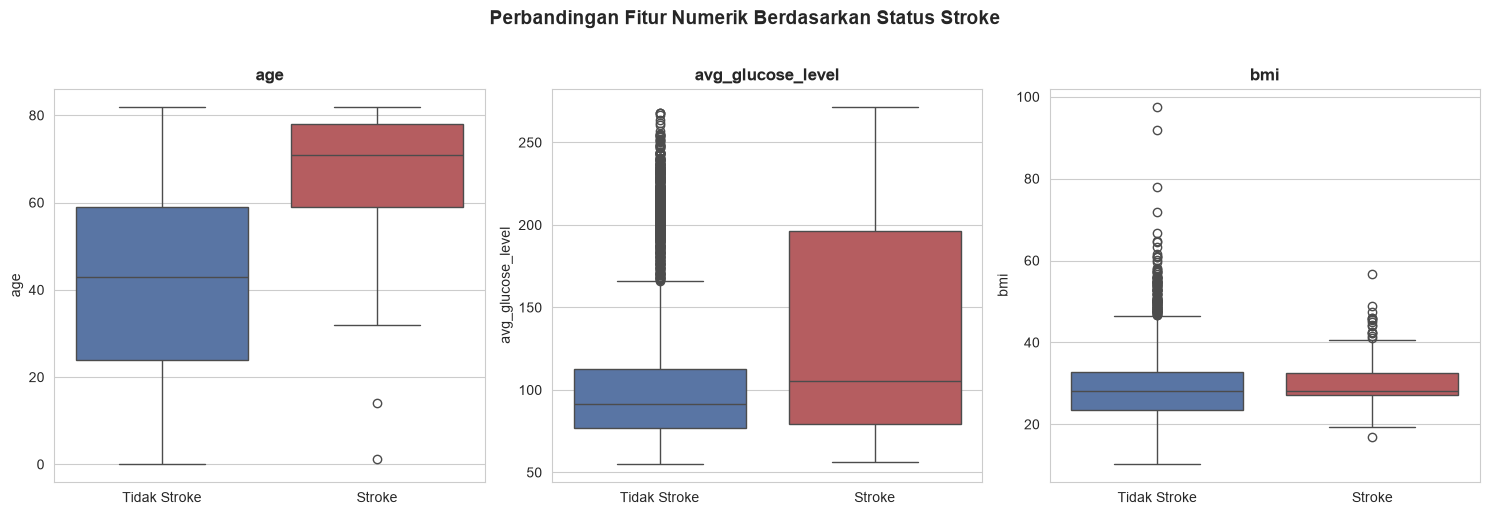

Chart disimpan: ../reports/figures/boxplot_numerik_vs_stroke.png


In [5]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='stroke', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Tidak Stroke', 'Stroke'])
    ax.set_xlabel('')

plt.suptitle('Perbandingan Fitur Numerik Berdasarkan Status Stroke', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/boxplot_numerik_vs_stroke.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart disimpan: {FIGURES_PATH}/boxplot_numerik_vs_stroke.png")

**Insight:** Boxplot `age` menunjukkan perbedaan paling mencolok — median usia kelompok stroke jauh lebih tinggi dibanding kelompok tidak stroke, sejalan dengan temuan rata-rata usia (42.0 vs 67.7 tahun). `avg_glucose_level` juga menunjukkan median yang lebih tinggi pada kelompok stroke, meski dengan sebaran yang lebih tumpang tindih antara kedua kelompok. `bmi` menunjukkan perbedaan median yang relatif kecil antara kedua kelompok, konsisten dengan korelasi linear yang lemah (r=0.037) pada NB05 — meski RF importance-nya tetap tinggi, mengindikasikan hubungan yang tidak sepenuhnya tertangkap lewat perbandingan median sederhana ini.

## 5. Perbandingan Fitur Kategorikal/Biner vs Status Stroke

**Tujuan:** Memvisualisasikan persentase kejadian stroke pada tiap kategori dari `hypertension`, `heart_disease`, dan `smoking_status` — versi visual dari hasil uji Chi-square pada NB05.

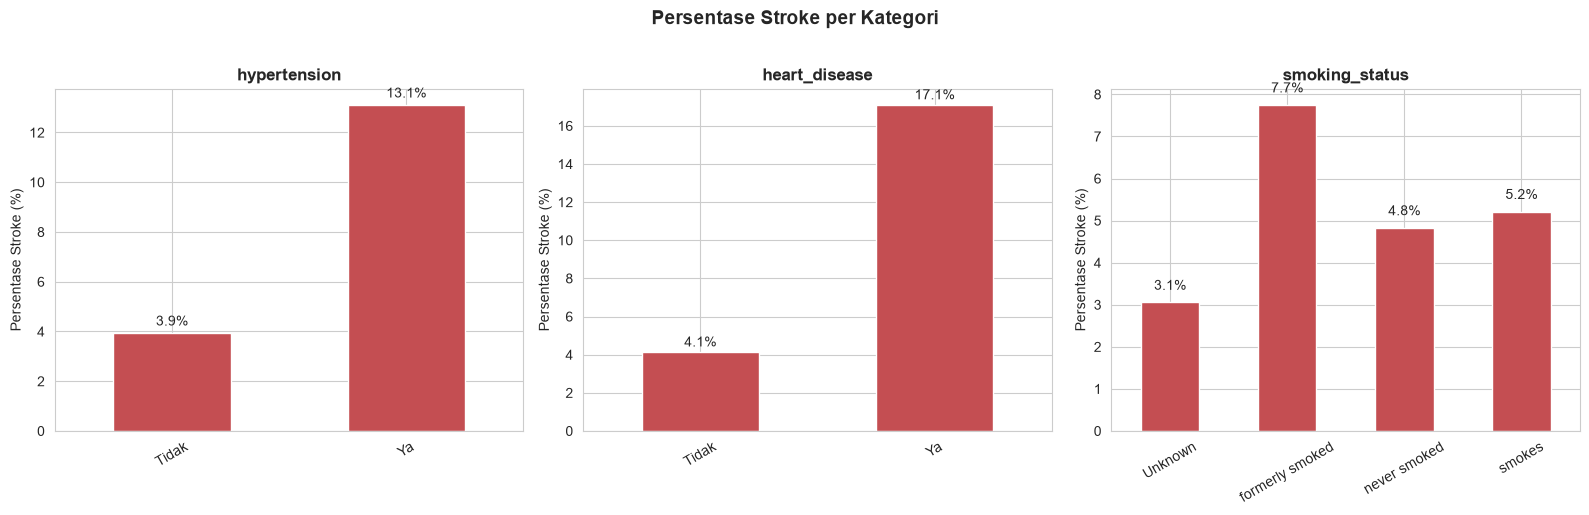

Chart disimpan: ../reports/figures/stroke_rate_per_kategori.png


In [6]:
cat_cols = ['hypertension', 'heart_disease', 'smoking_status']

df_viz = df.copy()
df_viz['hypertension'] = df_viz['hypertension'].map({0: 'Tidak', 1: 'Ya'})
df_viz['heart_disease'] = df_viz['heart_disease'].map({0: 'Tidak', 1: 'Ya'})

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, col in zip(axes, cat_cols):
    stroke_rate = df_viz.groupby(col)['stroke'].mean() * 100
    stroke_rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Persentase Stroke (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(stroke_rate.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Persentase Stroke per Kategori', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/stroke_rate_per_kategori.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart disimpan: {FIGURES_PATH}/stroke_rate_per_kategori.png")

**Insight:** Pasien dengan `hypertension` memiliki risiko stroke sekitar 3x lebih tinggi dibanding yang tidak (13.25% vs 3.97%), dan pasien dengan `heart_disease` sekitar 4x lebih tinggi (17.03% vs 4.18%) — perbedaan yang jauh lebih mencolok dibanding perbedaan median `bmi` pada boxplot Section 4. Ini menegaskan pentingnya fitur biner ini secara klinis, meskipun kontribusinya pada Random Forest importance (NB05) relatif kecil dibanding fitur numerik utama.

## 6. Kesimpulan

Notebook ini menghasilkan 4 visualisasi utama yang siap digunakan pada bagian hasil dan pembahasan paper, seluruhnya tersimpan di `reports/figures/`:

1. **`distribusi_target.png`** — menunjukkan imbalance signifikan pada target `stroke` (±95% vs ±5%), menjadi dasar visual bagi pembahasan accuracy paradox pada NB04.
2. **`distribusi_fitur_numerik.png`** — menunjukkan bentuk distribusi tiap fitur numerik, termasuk pola bimodal pada `avg_glucose_level` yang mendasari keputusan penggunaan domain knowledge (bukan IQR) untuk deteksi outlier pada NB03.
3. **`boxplot_numerik_vs_stroke.png`** — menunjukkan perbedaan sebaran nilai antara kelompok stroke dan tidak stroke, dengan `age` menunjukkan perbedaan paling mencolok, sejalan dengan hasil uji statistik pada NB05.
4. **`stroke_rate_per_kategori.png`** — menunjukkan bahwa pasien dengan `hypertension` dan `heart_disease` memiliki risiko stroke yang jauh lebih tinggi, memperkuat relevansi klinis kedua fitur ini meskipun kontribusi statistiknya (RF importance) relatif kecil dibanding fitur numerik utama.

Seluruh visualisasi dibuat dengan gaya dan skema warna yang konsisten (biru = tidak stroke, merah = stroke) serta resolusi tinggi (300 dpi), memudahkan tim penulisan paper untuk menggunakannya langsung tanpa perlu membuka atau menjalankan ulang notebook ini.